# PPU runtime weight-change diagnostic

This is a cleaned-up copy of `PPU_Test.ipynb` focused on one question: can a PPU kernel change synaptic weights during a run?

The original scratch notebook currently mixes three separate issues:

- The saved error `RuntimeError: No connection present` happens before the plasticity rule is tested. The previous cell calls `hxtorch.release_hardware()`, then the next cell starts a new `hxsnn.Experiment` without calling `hxtorch.init_hardware()` again.
- The first kernel cell is pseudocode: it has uninterpolated `{MODNET_N_OUT}` placeholders, undefined variables like `row`, `weights`, `spike_counts`, and an unfinished `modfactor =`.
- The smoke-test kernel should update the actual synapse view rows supplied by grenade, not hard-code `range(128)`. The working Pong notebook iterates `synapses[0].rows.size()` and writes row vectors with `set_weights(...)`.


In [126]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import torch
import torch.nn as nn
import torch.nn.functional as F
import quantities as pq

from dlens_vx_v3 import hal, halco
import pynn_brainscales.brainscales2 as pynn
from _static.common.helpers import setup_hardware_client, save_nightly_calibration
from _static.tutorial.hxsnn_intro_plots import plot_compare_traces

setup_hardware_client()

from hxtorch import snn as hxsnn
import hxtorch
import pygrenade_vx as grenade


hello
INFO  22:26:50,407  demo_helpers Connection to ['hxcube6fpga0chip65_1'] established


In [127]:
def ppu_words(values):
    block = hal.PPUMemoryBlock(halco.PPUMemoryBlockSize(len(values)))
    block.words = [hal.PPUMemoryWord(hal.PPUMemoryWord.Value(int(value))) for value in values]
    return block


def attach_ppu_symbols(exp, symbol_sizes):
    # The same symbol names must exist as volatile globals in the C++ kernel.
    exp.default_execution_instance.write_ppu_symbols = {
        name: {
            halco.HemisphereOnDLS.top: ppu_words([0] * size),
            halco.HemisphereOnDLS.bottom: ppu_words([0] * size),
        }
        for name, size in symbol_sizes.items()
    }
    exp.default_execution_instance.read_ppu_symbols = set(symbol_sizes)


def attach_ppu_debug_symbols(exp, names=("debug_runs", "debug_rows")):
    attach_ppu_symbols(exp, {name: 1 for name in names})


def read_ppu_symbols(exp, symbol_sizes):
    if not getattr(exp, "ppu_symbols_read", None):
        return {}

    out = {name: {} for name in symbol_sizes}
    ppu_read = exp.ppu_symbols_read[0]
    for _, symbols_by_chip in ppu_read.items():
        for chip, symbols in symbols_by_chip.items():
            for name, size in symbol_sizes.items():
                if name not in symbols:
                    continue
                for hemisphere, block in symbols[name].items():
                    out[name][str(hemisphere)] = [
                        int(block.words[index].value)
                        for index in range(size)
                    ]
    return out


def read_ppu_debug_symbols(exp, names=("debug_runs", "debug_rows")):
    values = read_ppu_symbols(exp, {name: 1 for name in names})
    return {
        name: {hemisphere: words[0] for hemisphere, words in hemispheres.items()}
        for name, hemispheres in values.items()
    }


In [128]:
def make_zero_weights_rule(start=5, period=10, num_periods=1):
    """Build a minimal hxtorch/grenade rule that zeros the supplied synapse views."""
    rule = grenade.network.PlasticityRule()
    rule.timer.start = grenade.network.PlasticityRule.Timer.Value(start)
    rule.timer.period = grenade.network.PlasticityRule.Timer.Value(period)
    rule.timer.num_periods = num_periods

    # hxtorch's signed Synapse path commonly exposes two synapse views.
    # The key point is to update the rows grenade actually supplies, not a hard-coded row count.
    rule.kernel = r"""
#include "grenade/vx/ppu/neuron_view_handle.h"
#include "grenade/vx/ppu/synapse_array_view_handle.h"
#include "libnux/vx/dls.h"
#include "libnux/vx/vector_row.h"
#include <array>

using namespace grenade::vx::ppu;
using namespace libnux::vx;

extern volatile PPUOnDLS ppu;
volatile uint32_t debug_runs;
volatile uint32_t debug_rows;

void PLASTICITY_RULE_KERNEL(
    std::array<SynapseArrayViewHandle, 2>& synapses,
    std::array<NeuronViewHandle, 0>& /* neurons */)
{
    debug_runs += 1;
    debug_rows = 0;

    for (size_t synapse_view = 0; synapse_view < synapses.size(); ++synapse_view) {
        if (synapses[synapse_view].hemisphere != ppu) {
            continue;
        }

        debug_rows += synapses[synapse_view].rows.size();
        for (size_t row = 0; row < synapses[synapse_view].rows.size(); ++row) {
            synapses[synapse_view].set_weights(VectorRowMod8(0), row);
        }
    }
}
"""
    return rule


In [129]:
def run_hxtorch_smoke_test(plasticity_rule=None, runtime=50, initial_weight=63):
    # Important: each independent run needs an active hxtorch hardware connection.
    hxtorch.init_hardware()
    try:
        save_nightly_calibration("spiking_calix-native.pkl")

        exp = hxsnn.Experiment(dt=1e-6)
        exp.default_execution_instance.load_calib("spiking_calix-native.pkl")
        if plasticity_rule is not None:
            attach_ppu_debug_symbols(exp)

        syn = hxsnn.Synapse(
            in_features=1,
            out_features=1,
            experiment=exp,
            plasticity_rule=plasticity_rule,
        )
        lif = hxsnn.LIF(
            size=1,
            experiment=exp,
            enable_cadc_recording=False,
            enable_madc_recording=(plasticity_rule is None),
            enable_spike_recording=True,
            record_neuron_id=0,
            cadc_time_shift=-1,
        )

        syn.weight.data.fill_(initial_weight)

        inputs = torch.zeros((runtime, 1, 1))
        for t in [10, 15, 20, 30]:
            if t < runtime:
                inputs[t] = 1

        g = syn(hxsnn.LIFObservables(spikes=inputs))
        z = lif(g)
        hxsnn.run(exp, runtime)

        print("spike tensor:", z.spikes.shape, "num spikes:", z.spikes.sum().item())
        if plasticity_rule is not None:
            print("PPU debug symbols:", read_ppu_debug_symbols(exp))

        if plasticity_rule is None:
            plot_compare_traces(inputs, z)
        return exp, syn, lif, z
    finally:
        hxtorch.release_hardware()


Baseline: weight stays at 63
spike tensor: torch.Size([50, 1, 1]) num spikes: 2.0


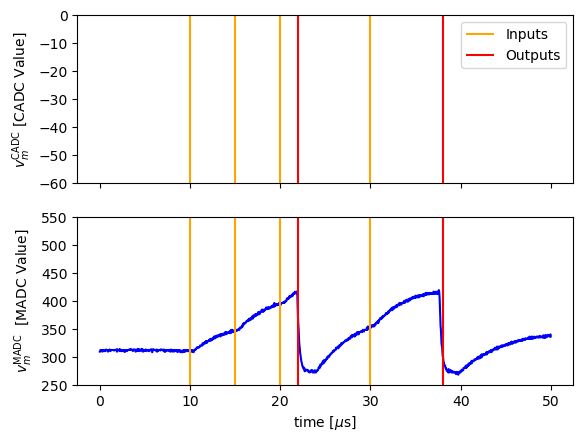

In [130]:
print("Baseline: weight stays at 63")
baseline_exp, baseline_syn, baseline_lif, baseline_z = run_hxtorch_smoke_test()


In [131]:
print("PPU test: weight is zeroed at t=5, before input spikes at 10/15/20/30")
zero_rule = make_zero_weights_rule(start=5, period=10, num_periods=1)
ppu_exp, ppu_syn, ppu_lif, ppu_z = run_hxtorch_smoke_test(plasticity_rule=zero_rule)


PPU test: weight is zeroed at t=5, before input spikes at 10/15/20/30
spike tensor: torch.Size([50, 1, 1]) num spikes: 2.0
PPU debug symbols: {'debug_runs': {'HemisphereOnDLS(0)': 0, 'HemisphereOnDLS(1)': 0}, 'debug_rows': {'HemisphereOnDLS(0)': 0, 'HemisphereOnDLS(1)': 0}}


### hxtorch plasticity-safe recording

hxtorch cannot run CADC recording and a plasticity rule in the same experiment. The plasticity demos below therefore use spike recording only. If you need membrane traces and runtime synapse readback together, the PyNN/Pong path is the better API surface.


## Showing Runtime Weight Changes During Inference

A final weight readback only tells us where the synapse memory ended up. To show that weights change *during inference*, we can make the PPU alternate the weight between high and zero while the same input spike train keeps arriving.

Expected effect: input spikes that land in high-weight windows should drive the neuron much more strongly than input spikes that land in zero-weight windows. This makes the runtime reconfiguration visible in spikes and membrane traces, even if we cannot stream the full synapse SRAM continuously back to Python.


In [132]:
def make_alternating_weights_rule(start=2, period=10, num_periods=8, high_weight=63, low_weight=0):
    """Alternate weights high/low during one hardware run and record a PPU-side history."""
    rule = grenade.network.PlasticityRule()
    rule.timer.start = grenade.network.PlasticityRule.Timer.Value(start)
    rule.timer.period = grenade.network.PlasticityRule.Timer.Value(period)
    rule.timer.num_periods = num_periods

    # The history arrays are read after the run. They are not host-side control;
    # they are written by the PPU kernel as it executes each scheduled update.
    rule.kernel = f"""
#include "grenade/vx/ppu/neuron_view_handle.h"
#include "grenade/vx/ppu/synapse_array_view_handle.h"
#include "libnux/vx/dls.h"
#include "libnux/vx/vector_row.h"
#include <array>

using namespace grenade::vx::ppu;
using namespace libnux::vx;

extern volatile PPUOnDLS ppu;
volatile uint32_t debug_runs;
volatile uint32_t debug_rows;
volatile uint32_t weight_history[{num_periods}];
volatile uint32_t measured_weight_history[{num_periods}];
uint32_t update_index = 0;

void PLASTICITY_RULE_KERNEL(
    std::array<SynapseArrayViewHandle, 2>& synapses,
    std::array<NeuronViewHandle, 0>& /* neurons */)
{{
    if (update_index >= {num_periods}) {{
        return;
    }}

    uint32_t commanded_weight = (update_index % 2 == 0) ? {high_weight} : {low_weight};
    uint32_t measured_weight = commanded_weight;

    debug_runs += 1;
    debug_rows = 0;
    weight_history[update_index] = commanded_weight;

    for (size_t synapse_view = 0; synapse_view < synapses.size(); ++synapse_view) {{
        if (synapses[synapse_view].hemisphere != ppu) {{
            continue;
        }}

        debug_rows += synapses[synapse_view].rows.size();
        for (size_t row = 0; row < synapses[synapse_view].rows.size(); ++row) {{
            synapses[synapse_view].set_weights(VectorRowMod8(commanded_weight), row);
        }}

        if (synapses[synapse_view].rows.size() > 0 && synapses[synapse_view].columns.size() > 0) {{
            VectorRowMod8 weights = synapses[synapse_view].get_weights(0);
            measured_weight = static_cast<uint32_t>(weights[synapses[synapse_view].columns[0]]);
        }}
    }}

    measured_weight_history[update_index] = measured_weight;
    update_index += 1;
}}
"""
    return rule


In [133]:
def make_regular_input(runtime, first_spike=7, every=5):
    inputs = torch.zeros((runtime, 1, 1))
    for t in range(first_spike, runtime, every):
        inputs[t] = 1
    return inputs


def _total_debug_runs(symbols):
    return sum(sum(words) for words in symbols.get("debug_runs", {}).values())


def run_alternating_inference_demo(runtime=90, start=2, period=10, num_periods=8):
    symbol_sizes = {
        "debug_runs": 1,
        "debug_rows": 1,
        "weight_history": num_periods,
        "measured_weight_history": num_periods,
    }

    hxtorch.init_hardware()
    try:
        save_nightly_calibration("spiking_calix-native.pkl")

        rule = make_alternating_weights_rule(
            start=start,
            period=period,
            num_periods=num_periods,
            high_weight=63,
            low_weight=0,
        )

        exp = hxsnn.Experiment(dt=1e-6)
        exp.default_execution_instance.load_calib("spiking_calix-native.pkl")
        attach_ppu_symbols(exp, symbol_sizes)

        syn = hxsnn.Synapse(
            in_features=1,
            out_features=1,
            experiment=exp,
            plasticity_rule=rule,
        )
        lif = hxsnn.LIF(
            size=1,
            experiment=exp,
            enable_cadc_recording=False,
            enable_madc_recording=False,
            enable_spike_recording=True,
        )

        # Start low so the only high-weight periods are created by the PPU.
        syn.weight.data.fill_(0)

        # Put spikes halfway between PPU updates, so each spike samples the
        # most recently written runtime weight instead of racing the update.
        first_spike = start + max(1, period // 2)
        inputs = make_regular_input(runtime, first_spike=first_spike, every=5)
        g = syn(hxsnn.LIFObservables(spikes=inputs))
        z = lif(g)
        hxsnn.run(exp, runtime)

        symbols = read_ppu_symbols(exp, symbol_sizes)
        print("PPU symbols:", symbols)
        print("num input spikes:", inputs.sum().item(), "num output spikes:", z.spikes.sum().item())

        if _total_debug_runs(symbols) == 0:
            print(
                "WARNING: debug_runs is 0, so the PPU kernel did not execute. "
                "Try the timer/signature heartbeat cells below before interpreting the trace."
            )

        plot_runtime_weight_effect(
            inputs,
            z,
            symbols,
            runtime=runtime,
            start=start,
            period=period,
            num_periods=num_periods,
        )
        return exp, syn, lif, z, symbols
    finally:
        hxtorch.release_hardware()


In [134]:
def _first_nonzero_history(symbols, name, num_periods):
    for words in symbols.get(name, {}).values():
        if any(words):
            return words
    return [np.nan] * num_periods


def _as_1d_numpy(value):
    if value is None:
        return None
    arr = value.detach().cpu().numpy() if hasattr(value, "detach") else np.asarray(value)
    return np.squeeze(arr).reshape(-1)


def _observed_trace(observables, *names):
    for name in names:
        value = getattr(observables, name, None)
        if value is not None:
            return _as_1d_numpy(value)
    return None


def plot_runtime_weight_effect(inputs, z, symbols, runtime, start, period, num_periods):
    commanded = _first_nonzero_history(symbols, "weight_history", num_periods)
    measured = _first_nonzero_history(symbols, "measured_weight_history", num_periods)

    t = np.arange(runtime)
    update_times = start + np.arange(num_periods) * period
    commanded_step = np.full(runtime, np.nan)
    measured_step = np.full(runtime, np.nan)
    for index, update_time in enumerate(update_times):
        next_time = update_times[index + 1] if index + 1 < len(update_times) else runtime
        if update_time >= runtime:
            continue
        commanded_step[update_time:min(next_time, runtime)] = commanded[index]
        measured_step[update_time:min(next_time, runtime)] = measured[index]

    input_trace = _as_1d_numpy(inputs)
    spike_trace = _observed_trace(z, "spikes")
    if spike_trace is None:
        spike_trace = np.zeros(runtime)

    # MADC/CADC traces may have fewer samples than the hxtorch dt grid.
    membrane = _observed_trace(z, "membrane_madc", "membrane_cadc")

    fig, axes = plt.subplots(3 if membrane is not None else 2, 1, sharex=False, figsize=(11, 7))

    axes[0].step(t, commanded_step, where="post", label="commanded by PPU", linewidth=2)
    axes[0].step(t, measured_step, where="post", label="read back inside PPU", linestyle="--", linewidth=1.5)
    axes[0].set_ylabel("weight")
    axes[0].set_ylim(-5, 68)
    axes[0].legend(loc="upper right")
    axes[0].set_title("Runtime synaptic weight schedule during one inference run")

    axes[1].eventplot(np.flatnonzero(input_trace[:runtime]), lineoffsets=1.0, colors="black", label="input spikes")
    if spike_trace.sum() > 0:
        axes[1].eventplot(np.flatnonzero(spike_trace[:runtime]), lineoffsets=0.5, colors="tab:red", label="output spikes")
    axes[1].set_yticks([0.5, 1.0], ["out", "in"])
    axes[1].set_ylabel("spikes")
    axes[1].set_xlim(0, runtime)
    axes[1].legend(loc="upper right")

    if membrane is not None:
        membrane_t = np.linspace(0, runtime, len(membrane), endpoint=False)
        axes[2].plot(membrane_t, membrane, color="tab:blue", marker="o" if len(membrane) < 20 else None)
        axes[2].set_ylabel("membrane readout")
        axes[2].set_xlabel("time step")
        axes[2].set_xlim(0, runtime)
    else:
        axes[1].set_xlabel("time step")

    for ax in axes:
        ax.set_xlim(0, runtime)
        for index, update_time in enumerate(update_times):
            if index % 2 == 0:
                ax.axvspan(update_time, min(update_time + period, runtime), color="tab:green", alpha=0.08)

    plt.tight_layout()


PPU symbols: {'debug_runs': {'HemisphereOnDLS(0)': [0], 'HemisphereOnDLS(1)': [0]}, 'debug_rows': {'HemisphereOnDLS(0)': [0], 'HemisphereOnDLS(1)': [0]}, 'weight_history': {'HemisphereOnDLS(0)': [0, 0, 0, 0, 0, 0, 0, 0], 'HemisphereOnDLS(1)': [0, 0, 0, 0, 0, 0, 0, 0]}, 'measured_weight_history': {'HemisphereOnDLS(0)': [0, 0, 0, 0, 0, 0, 0, 0], 'HemisphereOnDLS(1)': [0, 0, 0, 0, 0, 0, 0, 0]}}
num input spikes: 17.0 num output spikes: 0.0


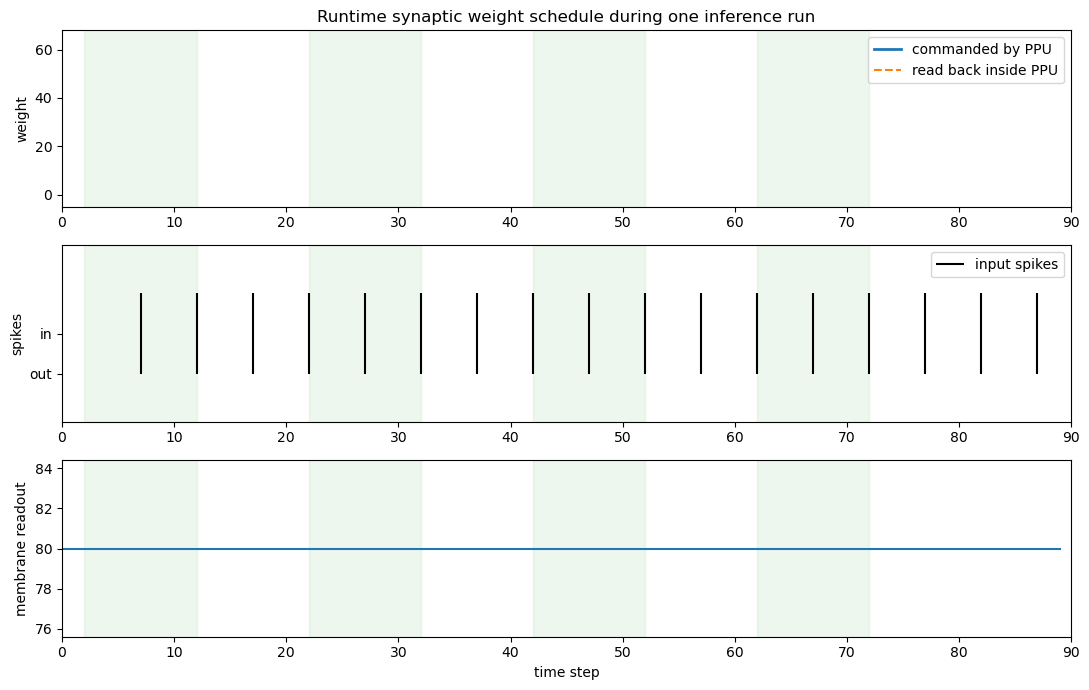

In [135]:
alt_exp, alt_syn, alt_lif, alt_z, alt_symbols = run_alternating_inference_demo(
    runtime=90,
    start=2,
    period=10,
    num_periods=8,
)


The green shaded windows are the high-weight inference windows. If runtime weight modulation is working, the same input spike train should have a visibly different effect in high-weight windows than in zero-weight windows.

Two details to keep in mind:

- `weight_history` is the value the PPU decided to write at each scheduled update.
- `measured_weight_history` is a small PPU-side spot-check immediately after writing. The full synapse matrix is not continuously streamed to Python during the run, so the most convincing runtime demonstration is the combination of the PPU-side history plus the neuron response changing within the same run.


## If `debug_runs` Is Still Zero

If the alternating demo says `debug_runs == 0`, the problem is not the plotting and not the weight value: hxtorch/grenade did not schedule the PPU kernel. This heartbeat test tries only to increment a symbol, with no synapse read/write logic, so it isolates timer/signature issues.


In [136]:
def make_ppu_heartbeat_rule(start=2, period=10, num_periods=3, synapse_views=2):
    rule = grenade.network.PlasticityRule()
    rule.timer.start = grenade.network.PlasticityRule.Timer.Value(start)
    rule.timer.period = grenade.network.PlasticityRule.Timer.Value(period)
    rule.timer.num_periods = num_periods
    rule.kernel = f"""
#include "grenade/vx/ppu/neuron_view_handle.h"
#include "grenade/vx/ppu/synapse_array_view_handle.h"
#include <array>

using namespace grenade::vx::ppu;
volatile uint32_t debug_runs;
volatile uint32_t debug_rows;

void PLASTICITY_RULE_KERNEL(
    std::array<SynapseArrayViewHandle, {synapse_views}>& synapses,
    std::array<NeuronViewHandle, 0>& /* neurons */)
{{
    debug_runs += 1;
    debug_rows = synapses.size();
}}
"""
    return rule


def run_ppu_heartbeat(start=2, period=10, num_periods=3, synapse_views=2, runtime=50):
    hxtorch.init_hardware()
    try:
        save_nightly_calibration("spiking_calix-native.pkl")
        exp = hxsnn.Experiment(dt=1e-6)
        exp.default_execution_instance.load_calib("spiking_calix-native.pkl")
        attach_ppu_debug_symbols(exp)

        rule = make_ppu_heartbeat_rule(
            start=start,
            period=period,
            num_periods=num_periods,
            synapse_views=synapse_views,
        )
        syn = hxsnn.Synapse(in_features=1, out_features=1, experiment=exp, plasticity_rule=rule)
        lif = hxsnn.LIF(
            size=1,
            experiment=exp,
            enable_cadc_recording=False,
            enable_madc_recording=False,
            enable_spike_recording=True,
        )
        syn.weight.data.fill_(1)
        inputs = make_regular_input(runtime, first_spike=5, every=10)
        z = lif(syn(hxsnn.LIFObservables(spikes=inputs)))
        hxsnn.run(exp, runtime)
        symbols = read_ppu_debug_symbols(exp)
        print(symbols)
        return symbols
    finally:
        hxtorch.release_hardware()


In [137]:
# First try the hxtorch-style 2-view signature. If this compiles but stays zero,
# change synapse_views to 1 below and rerun the cell.
heartbeat_symbols = run_ppu_heartbeat(start=2, period=10, num_periods=3, synapse_views=2, runtime=50)


{'debug_runs': {'HemisphereOnDLS(0)': 0, 'HemisphereOnDLS(1)': 0}, 'debug_rows': {'HemisphereOnDLS(0)': 0, 'HemisphereOnDLS(1)': 0}}


## PyNN Runtime Weight Toggle Demo

The hxtorch heartbeat staying at zero means the hxtorch test is not a useful proof path right now. The working Pong notebook uses PyNN plasticity rules, so this section uses the same PPU scheduling route.

This demo changes weights during one inference run and records PPU observables on every scheduled update. It also records output spikes, so you can see both the commanded weight timeline and its inference-time effect.


In [138]:
class ToggleWeightRule(pynn.PlasticityRule):
    """PPU rule that alternates one projection between high and low weights."""

    def __init__(self, timer, high_weight=63, low_weight=0):
        observables = {
            "commanded_weight": pynn.PlasticityRule.ObservableArray(),
            "measured_weight": pynn.PlasticityRule.ObservableArray(),
        }
        observables["commanded_weight"].type = pynn.PlasticityRule.ObservableArray.Type.uint8
        observables["commanded_weight"].size = 1
        observables["measured_weight"].type = pynn.PlasticityRule.ObservableArray.Type.uint8
        observables["measured_weight"].size = 1
        super().__init__(timer=timer, observables=observables)
        self.high_weight = int(high_weight)
        self.low_weight = int(low_weight)

    def generate_kernel(self) -> str:
        return textwrap.dedent(f"""
        #include "grenade/vx/ppu/synapse_array_view_handle.h"
        #include "grenade/vx/ppu/neuron_view_handle.h"
        #include "libnux/vx/dls.h"
        #include <array>

        using namespace grenade::vx::ppu;
        using namespace libnux::vx;

        extern volatile PPUOnDLS ppu;
        uint32_t update_index = 0;

        void PLASTICITY_RULE_KERNEL(
            std::array<SynapseArrayViewHandle, 1>& synapses,
            std::array<NeuronViewHandle, 0>& /* neurons */,
            Recording& recording)
        {{
            if (synapses[0].hemisphere != ppu) {{
                return;
            }}

            uint8_t commanded_weight = (update_index % 2 == 0)
                ? {self.high_weight}
                : {self.low_weight};

            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                vector_row_t weight_row;
                for (auto const column: synapses[0].columns) {{
                    weight_row[column] = commanded_weight;
                }}
                synapses[0].set_weights(weight_row, row);
            }}

            uint8_t measured_weight = commanded_weight;
            if (synapses[0].rows.size() > 0 && synapses[0].columns.size() > 0) {{
                auto weights = synapses[0].get_weights(0);
                measured_weight = weights[synapses[0].columns[0]];
            }}

            recording.commanded_weight[0] = commanded_weight;
            recording.measured_weight[0] = measured_weight;
            update_index++;
        }}
        """)


In [139]:
def _observable_values(rule, name, num_periods):
    observed = rule.get_observable_array(name)[0]
    return np.array([int(observed[i].data[0]) for i in range(num_periods)])


def plot_pynn_runtime_weight_demo(input_spike_times, output_spiketrains, commanded, measured, runtime, period):
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 5))
    update_times = np.arange(len(commanded)) * period

    t = np.arange(runtime)
    commanded_step = np.repeat(commanded, period)[:runtime]
    measured_step = np.repeat(measured, period)[:runtime]
    axes[0].step(t, commanded_step, where="post", label="commanded by PPU", linewidth=2)
    axes[0].step(t, measured_step, where="post", label="read back inside PPU", linestyle="--")
    axes[0].set_ylabel("weight")
    axes[0].set_ylim(-5, 68)
    axes[0].legend(loc="upper right")
    axes[0].set_title("PyNN/PPU runtime weight updates during inference")

    axes[1].eventplot([input_spike_times], lineoffsets=[1.0], colors=["black"], label="input spikes")
    out = [np.asarray(st.base) for st in output_spiketrains]
    if out:
        axes[1].eventplot(out, lineoffsets=np.arange(len(out)) * 0.1 + 0.35, colors="tab:red", label="output spikes")
    axes[1].set_yticks([0.5, 1.0], ["out", "in"])
    axes[1].set_xlabel("time [ms]")
    axes[1].set_ylabel("spikes")
    axes[1].legend(loc="upper right")

    for ax in axes:
        ax.set_xlim(0, runtime)
        for index, update_time in enumerate(update_times):
            if index % 2 == 0:
                ax.axvspan(update_time, min(update_time + period, runtime), color="tab:green", alpha=0.08)
    plt.tight_layout()


In [140]:
def run_pynn_runtime_weight_demo(runtime=80, period=10, num_periods=8):
    # This follows the official plasticity-rate-coding demo: bypass mode makes
    # spikes a clean readout of whether the currently written synapse is active.
    pynn.setup(enable_neuron_bypass=True)
    try:
        input_spike_times = np.arange(1, runtime, 1.0)
        pop_input = pynn.Population(
            1,
            pynn.cells.SpikeSourceArray(spike_times=[input_spike_times]),
        )
        pop_output = pynn.Population(1, pynn.cells.HXNeuron())
        pop_output.record(["spikes"])

        timer = pynn.Timer(start=0.0, period=float(period), num_periods=num_periods)
        plasticity_rule = ToggleWeightRule(timer=timer, high_weight=63, low_weight=0)
        synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=plasticity_rule,
            weight=0,
        )
        projection = pynn.Projection(
            pop_input,
            pop_output,
            pynn.OneToOneConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )

        pynn.run(runtime)

        commanded = _observable_values(plasticity_rule, "commanded_weight", num_periods)
        measured = _observable_values(plasticity_rule, "measured_weight", num_periods)
        spikes = pop_output.get_data("spikes").segments[0].spiketrains

        print("commanded weights:", commanded.tolist())
        print("measured weights:", measured.tolist())
        print("output spike count:", sum(len(st) for st in spikes))

        plot_pynn_runtime_weight_demo(input_spike_times, spikes, commanded, measured, runtime, period)
        return commanded, measured, spikes, projection
    finally:
        pynn.end()


commanded weights: [63, 0, 63, 0, 63, 0, 63, 0]
measured weights: [63, 0, 63, 0, 63, 0, 63, 0]
output spike count: 40


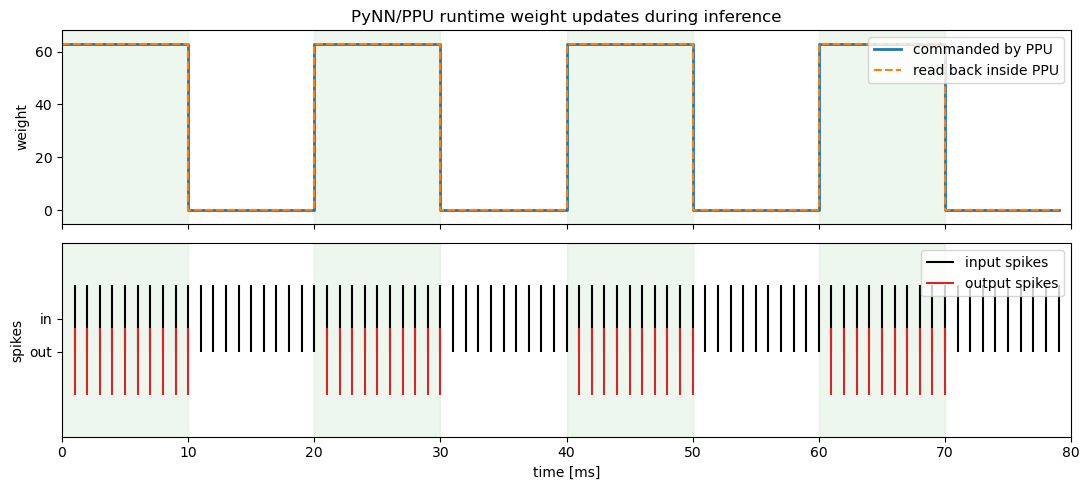

In [141]:
commanded, measured, pynn_spikes, pynn_projection = run_pynn_runtime_weight_demo(
    runtime=80,
    period=10,
    num_periods=8,
)


## ANN Release-Site Weight Schedule

This is the next bridge from your `weight_modulation.py` idea to hardware. We use a tiny untrained ANN to emit release amplitudes and spreads at fixed output-neuron release sites. Those release fields are accumulated into a weight matrix schedule on the host, then embedded into the PPU kernel.

So the ANN determines the weight updates, and the PPU applies those updates during one `pynn.run(...)`. This proves the hardware plumbing for ANN-determined runtime weights. The ANN itself is not yet running on the PPU; moving ANN inference on-chip would be a later step.


In [142]:
class TinyReleaseANN(torch.nn.Module):
    """Small untrained ANN that emits release amplitudes and spreads."""

    def __init__(self, n_features=4, n_release_sites=4, hidden=16, seed=7):
        super().__init__()
        torch.manual_seed(seed)
        self.n_release_sites = int(n_release_sites)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_features, hidden),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden, 2 * self.n_release_sites),
        )
        with torch.no_grad():
            for module in self.net:
                if isinstance(module, torch.nn.Linear):
                    torch.nn.init.normal_(module.weight, mean=0.0, std=0.45)
                    torch.nn.init.normal_(module.bias, mean=0.0, std=0.15)

    def forward(self, features):
        raw = self.net(features)
        amps = torch.tanh(raw[:, :self.n_release_sites])
        spreads = torch.sigmoid(raw[:, self.n_release_sites:])
        return amps, spreads


def release_sites_1d(n_outputs, n_release_sites):
    if n_release_sites == 1:
        return np.array([n_outputs // 2], dtype=int)
    return np.rint(np.linspace(0, n_outputs - 1, n_release_sites)).astype(int)


def release_field_1d(amps, spreads, sites, n_outputs):
    positions = torch.arange(n_outputs, dtype=torch.float32).view(1, 1, n_outputs)
    site_pos = torch.tensor(sites, dtype=torch.float32).view(1, len(sites), 1)
    max_dist = max(1.0, float(n_outputs - 1))
    sigma = (spreads.unsqueeze(2) * max_dist).clamp_min(0.35)
    kernels = torch.exp(-0.5 * ((positions - site_pos) / sigma) ** 2)
    numerator = torch.sum(amps.unsqueeze(2) * kernels, dim=1)
    denom = torch.sum(kernels, dim=1).clamp_min(1e-6)
    return numerator / denom


def build_ann_release_weight_schedule(
    n_outputs=16,
    n_release_sites=4,
    num_periods=12,
    base_weight=24,
    delta_scale=18,
    seed=7,
):
    """Host-side ANN creates release amplitudes/spreads; fields are added into weights."""
    ann = TinyReleaseANN(n_release_sites=n_release_sites, seed=seed)
    sites = release_sites_1d(n_outputs, n_release_sites)

    phase = torch.linspace(0, 2 * torch.pi, num_periods)
    features = torch.stack([
        torch.sin(phase),
        torch.cos(phase),
        torch.linspace(-1, 1, num_periods),
        torch.ones(num_periods),
    ], dim=1)

    with torch.no_grad():
        amps, spreads = ann(features)
        fields = release_field_1d(amps, spreads, sites, n_outputs)

    weights = torch.full((num_periods, n_outputs), float(base_weight))
    current = weights[0].clone()
    for update in range(num_periods):
        current = torch.clamp(current + delta_scale * fields[update], 0, 63)
        weights[update] = current

    schedule = torch.round(weights).to(torch.uint8).cpu().numpy()
    diagnostics = {
        "sites": sites,
        "features": features.cpu().numpy(),
        "amps": amps.cpu().numpy(),
        "spreads": spreads.cpu().numpy(),
        "fields": fields.cpu().numpy(),
        "schedule": schedule,
    }
    return schedule, diagnostics


def plot_ann_release_schedule(diagnostics, period=10):
    schedule = diagnostics["schedule"]
    amps = diagnostics["amps"]
    spreads = diagnostics["spreads"]
    sites = diagnostics["sites"]

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
    im = axes[0].imshow(schedule.T, aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[0].set_ylabel("output neuron")
    axes[0].set_title("ANN-determined weight schedule sent to the PPU")
    axes[0].set_xticks(np.arange(schedule.shape[0]), [f"{i * period:g}" for i in range(schedule.shape[0])])
    axes[0].set_xlabel("update time [ms]")
    for site in sites:
        axes[0].axhline(site, color="white", alpha=0.35, linewidth=1)
    fig.colorbar(im, ax=axes[0], label="weight")

    axes[1].plot(amps, marker="o")
    axes[1].set_ylabel("amplitude")
    axes[1].set_title("ANN release amplitudes")
    axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.4)

    axes[2].plot(spreads, marker="o")
    axes[2].set_ylabel("spread")
    axes[2].set_xlabel("update index")
    axes[2].set_title("ANN release spreads")


In [143]:
class ANNReleaseScheduleRule(pynn.PlasticityRule):
    """PPU rule that applies a host ANN-generated vector schedule at runtime."""

    def __init__(self, timer, schedule):
        self.schedule = np.asarray(schedule, dtype=np.uint8)
        self.num_periods, self.n_outputs = self.schedule.shape
        observables = {
            "mean_weight": pynn.PlasticityRule.ObservableArray(),
            "first_weight": pynn.PlasticityRule.ObservableArray(),
        }
        observables["mean_weight"].type = pynn.PlasticityRule.ObservableArray.Type.uint8
        observables["mean_weight"].size = 1
        observables["first_weight"].type = pynn.PlasticityRule.ObservableArray.Type.uint8
        observables["first_weight"].size = 1
        super().__init__(timer=timer, observables=observables)

    def generate_kernel(self) -> str:
        rows = ",\n".join(
            "            {" + ", ".join(str(int(v)) for v in row) + "}"
            for row in self.schedule
        )
        return textwrap.dedent(f"""
        #include "grenade/vx/ppu/synapse_array_view_handle.h"
        #include "grenade/vx/ppu/neuron_view_handle.h"
        #include "libnux/vx/dls.h"
        #include <array>

        using namespace grenade::vx::ppu;
        using namespace libnux::vx;

        extern volatile PPUOnDLS ppu;
        uint32_t update_index = 0;
        uint8_t ann_schedule[{self.num_periods}][{self.n_outputs}] = {{
{rows}
        }};

        void PLASTICITY_RULE_KERNEL(
            std::array<SynapseArrayViewHandle, 1>& synapses,
            std::array<NeuronViewHandle, 0>& /* neurons */,
            Recording& recording)
        {{
            if (synapses[0].hemisphere != ppu) {{
                return;
            }}
            if (update_index >= {self.num_periods}) {{
                return;
            }}

            uint32_t sum = 0;
            vector_row_t weight_row;
            for (size_t idx = 0; idx < synapses[0].columns.size(); ++idx) {{
                auto const column = synapses[0].columns[idx];
                uint8_t weight = ann_schedule[update_index][idx % {self.n_outputs}];
                weight_row[column] = weight;
                sum += weight;
            }}
            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                synapses[0].set_weights(weight_row, row);
            }}

            recording.first_weight[0] = ann_schedule[update_index][0];
            recording.mean_weight[0] = sum / std::max<size_t>(1, synapses[0].columns.size());
            update_index++;
        }}
        """)


def _ann_observable(rule, name, num_periods):
    observed = rule.get_observable_array(name)[0]
    return np.array([int(observed[i].data[0]) for i in range(num_periods)])


In [144]:
def plot_ann_hardware_result(input_spike_times, output_spiketrains, schedule, mean_weight, first_weight, period, runtime):
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)

    axes[0].imshow(schedule.T, aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[0].set_ylabel("output neuron")
    axes[0].set_title("ANN schedule embedded in PPU kernel")

    t = np.arange(len(mean_weight)) * period
    axes[1].plot(t, schedule.mean(axis=1), label="host ANN schedule mean", linewidth=2)
    axes[1].plot(t, mean_weight, "o--", label="PPU recorded mean")
    axes[1].plot(t, first_weight, "s--", label="PPU recorded first col")
    axes[1].set_ylabel("weight")
    axes[1].set_ylim(-5, 68)
    axes[1].legend(loc="upper right")

    axes[2].eventplot([input_spike_times], lineoffsets=[schedule.shape[0] + 1], colors=["black"], label="input")
    spike_times = [np.asarray(st.base) for st in output_spiketrains]
    if spike_times:
        axes[2].eventplot(spike_times, lineoffsets=np.arange(len(spike_times)), colors="tab:red")
    axes[2].set_ylabel("output neuron")
    axes[2].set_xlabel("time [ms]")
    axes[2].set_xlim(0, runtime)
    axes[2].set_title("Output spikes while ANN-determined weights change")


def run_pynn_ann_release_schedule_demo(n_outputs=16, runtime=120, period=10, num_periods=12, seed=7):
    schedule, diagnostics = build_ann_release_weight_schedule(
        n_outputs=n_outputs,
        n_release_sites=4,
        num_periods=num_periods,
        seed=seed,
    )
    plot_ann_release_schedule(diagnostics, period=period)

    pynn.setup(enable_neuron_bypass=True)
    try:
        input_spike_times = np.arange(1, runtime, 1.0)
        pop_input = pynn.Population(
            1,
            pynn.cells.SpikeSourceArray(spike_times=[input_spike_times]),
        )
        pop_output = pynn.Population(n_outputs, pynn.cells.HXNeuron())
        pop_output.record(["spikes"])

        timer = pynn.Timer(start=0.0, period=float(period), num_periods=num_periods)
        plasticity_rule = ANNReleaseScheduleRule(timer=timer, schedule=schedule)
        synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=plasticity_rule,
            weight=0,
        )
        projection = pynn.Projection(
            pop_input,
            pop_output,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )

        pynn.run(runtime)

        mean_weight = _ann_observable(plasticity_rule, "mean_weight", num_periods)
        first_weight = _ann_observable(plasticity_rule, "first_weight", num_periods)
        spikes = pop_output.get_data("spikes").segments[0].spiketrains

        print("ANN release sites:", diagnostics["sites"].tolist())
        print("host schedule mean:", np.rint(schedule.mean(axis=1)).astype(int).tolist())
        print("PPU mean_weight:", mean_weight.tolist())
        print("PPU first_weight:", first_weight.tolist())
        print("output spike count:", sum(len(st) for st in spikes))

        plot_ann_hardware_result(input_spike_times, spikes, schedule, mean_weight, first_weight, period, runtime)
        return schedule, diagnostics, mean_weight, first_weight, spikes, projection
    finally:
        pynn.end()


ANN release sites: [0, 5, 10, 15]
host schedule mean: [32, 40, 45, 44, 39, 33, 27, 23, 21, 26, 34, 40]
PPU mean_weight: [32, 40, 45, 44, 39, 33, 27, 22, 21, 26, 34, 40]
PPU first_weight: [36, 48, 57, 60, 55, 46, 37, 31, 36, 50, 63, 63]
output spike count: 1267


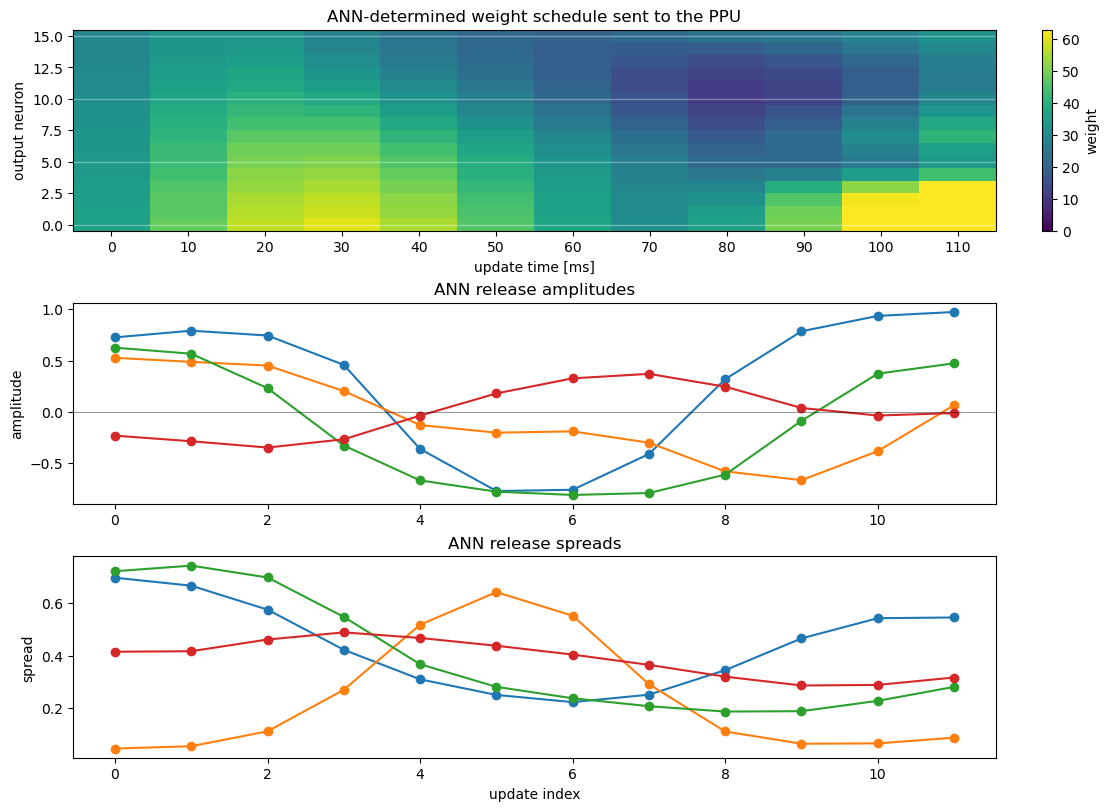

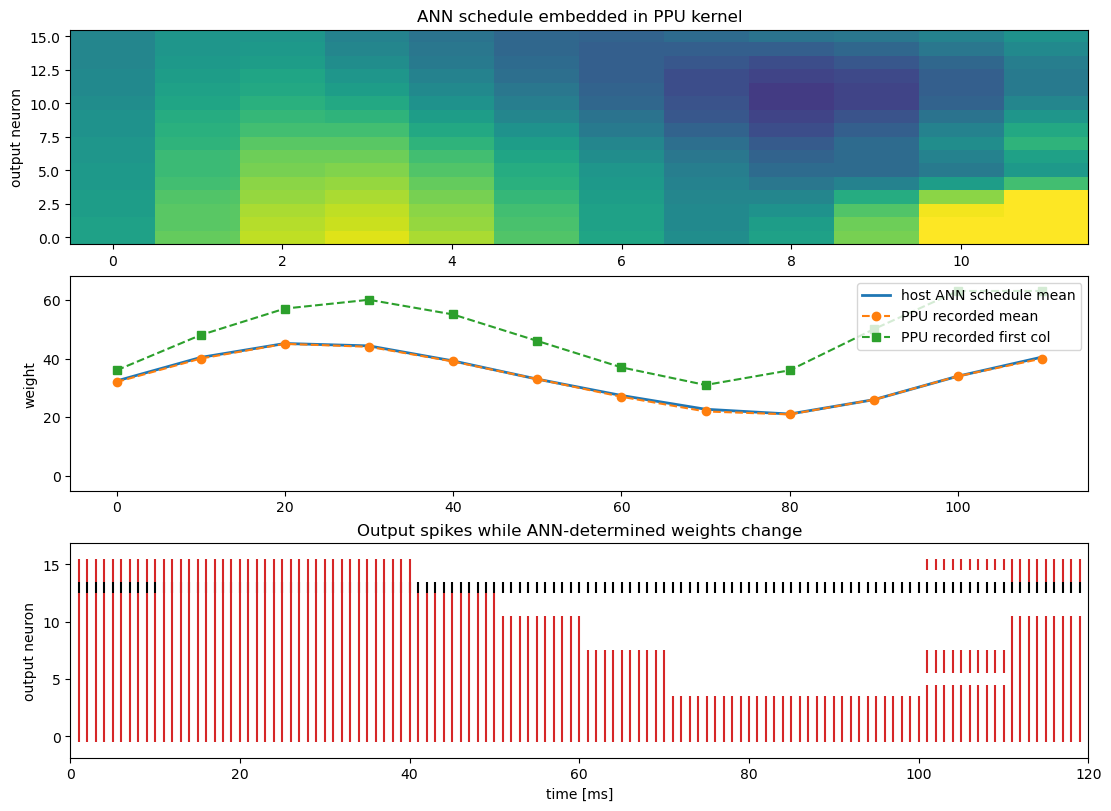

In [145]:
ann_schedule, ann_diagnostics, ann_mean_weight, ann_first_weight, ann_spikes, ann_projection = \
    run_pynn_ann_release_schedule_demo(
        n_outputs=16,
        runtime=120,
        period=10,
        num_periods=12,
        seed=7,
    )


## Surrogate-Gradient SNN With ANN Runtime Modulator

This is the software training version of the idea in `weight_modulation.py`: an SNN runs forward in time, and every few timesteps an ANN observes recent activity plus compact weight summaries, emits release amplitudes/spreads, and edits the SNN readout weights while the sample is still being processed.

This section trains that ANN modulator with surrogate gradients on a small YinYang-like task. After training, we export one sample's modulated readout-weight schedule and send it through the already-working PyNN/PPU runtime schedule path.

Boundary check: the training and ANN inference here are PyTorch/off-chip. The PPU part applies the trained ANN's generated schedule during hardware runtime. That is the right next plumbing test before attempting to port the ANN itself into PPU C++.


In [146]:
class SurrGradSpike(torch.autograd.Function):
    scale = 25.0

    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 0).to(input.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        (inp,) = ctx.saved_tensors
        return grad_output / (SurrGradSpike.scale * inp.abs() + 1.0) ** 2


sg_spike = SurrGradSpike.apply


def make_yinyang_like_tensors(n_samples=768, seed=3):
    """Small self-contained fallback if hxtorch's YinYangDataset is unavailable."""
    try:
        from hxtorch.snn.datasets.yinyang import YinYangDataset
        dataset = YinYangDataset(size=n_samples)
        xs, ys = [], []
        for idx in range(n_samples):
            x_item, y_item = dataset[idx]
            x_tensor = torch.as_tensor(x_item, dtype=torch.float32).flatten()
            if x_tensor.numel() < 4:
                xy = x_tensor[:2]
                x_tensor = torch.cat([xy, 1.0 - xy])
            xs.append(x_tensor[:4])
            ys.append(int(y_item))
        x = torch.stack(xs)
        y = torch.tensor(ys, dtype=torch.long)
        source = "hxtorch YinYangDataset"
    except Exception:
        rng = np.random.default_rng(seed)
        radius = np.sqrt(rng.random(n_samples)) * 0.5
        theta = rng.random(n_samples) * 2 * np.pi
        x0 = 0.5 + radius * np.cos(theta)
        x1 = 0.5 + radius * np.sin(theta)
        warped = theta + 1.25 * np.sin(3.0 * radius / 0.5)
        y_np = np.floor(((warped + np.pi) % (2 * np.pi)) / (2 * np.pi / 3)).astype(np.int64)
        x = torch.tensor(np.stack([x0, x1, 1.0 - x0, 1.0 - x1], axis=1), dtype=torch.float32)
        y = torch.tensor(y_np, dtype=torch.long)
        source = "synthetic YinYang-like fallback"

    perm = torch.randperm(n_samples, generator=torch.Generator().manual_seed(seed))
    x = torch.nan_to_num(x[perm].float(), nan=0.5, posinf=1.0, neginf=0.0).clamp(0, 1)
    y = y[perm].long().clamp(0, 2)
    split = int(0.8 * n_samples)
    return {
        "train_x": x[:split],
        "train_y": y[:split],
        "test_x": x[split:],
        "test_y": y[split:],
        "source": source,
    }


def plot_yinyang_like_data(data, max_points=700):
    x = torch.cat([data["train_x"], data["test_x"]], dim=0)[:max_points].cpu().numpy()
    y = torch.cat([data["train_y"], data["test_y"]], dim=0)[:max_points].cpu().numpy()
    plt.figure(figsize=(5, 5))
    plt.scatter(x[:, 0], x[:, 1], c=y, s=12, cmap="tab10", alpha=0.8)
    plt.gca().set_aspect("equal")
    plt.title(f"YinYang training task source: {data['source']}")
    plt.xlabel("x")
    plt.ylabel("y")


In [147]:
def release_sites_1d_torch(n, count, device=None):
    device = device or torch.device("cpu")
    if count <= 1:
        return torch.tensor([n // 2], device=device, dtype=torch.long)
    return torch.round(torch.linspace(0, n - 1, count, device=device)).long().clamp(0, n - 1)


def release_field_1d_torch(amps, spreads, sites, n_outputs):
    positions = torch.arange(n_outputs, device=amps.device, dtype=amps.dtype).view(1, 1, n_outputs)
    site_pos = sites.to(device=amps.device, dtype=amps.dtype).view(1, -1, 1)
    max_dist = max(1.0, float(n_outputs - 1))
    sigma = (spreads.unsqueeze(2) * max_dist).clamp_min(0.35)
    kernels = torch.exp(-0.5 * ((positions - site_pos) / sigma) ** 2)
    numerator = torch.sum(amps.unsqueeze(2) * kernels, dim=1)
    denom = torch.sum(kernels, dim=1).clamp_min(1e-6)
    return numerator / denom


class SurrogateReleaseModulatedSNN(nn.Module):
    """Stable toy SNN whose readout weights are edited by an ANN during one sample."""

    def __init__(
        self,
        n_inputs=5,
        n_hidden=32,
        n_outputs=3,
        n_release_sites=3,
        n_steps=30,
        ann_interval=5,
        delta_scale=0.06,
        seed=11,
    ):
        super().__init__()
        torch.manual_seed(seed)
        self.n_inputs = int(n_inputs)
        self.n_hidden = int(n_hidden)
        self.n_outputs = int(n_outputs)
        self.n_release_sites = int(n_release_sites)
        self.n_steps = int(n_steps)
        self.ann_interval = int(ann_interval)
        self.delta_scale = float(delta_scale)
        self.release_sites = release_sites_1d_torch(n_outputs, n_release_sites)

        self.w_in = nn.Parameter(torch.randn(n_inputs, n_hidden) * 0.18)
        self.w_out = nn.Parameter(torch.randn(n_hidden, n_outputs) * 0.10)
        self.hidden_bias = nn.Parameter(torch.zeros(n_hidden))
        self.out_bias = nn.Parameter(torch.zeros(n_outputs))

        mod_in_dim = n_inputs + n_hidden + n_outputs + 3 * n_release_sites
        mod_out_dim = 2 * n_release_sites
        self.modulator = nn.Sequential(
            nn.Linear(mod_in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, mod_out_dim),
        )
        with torch.no_grad():
            for module in self.modulator:
                if isinstance(module, nn.Linear):
                    nn.init.normal_(module.weight, mean=0.0, std=0.03)
                    nn.init.zeros_(module.bias)

    def encode(self, x):
        # YinYang tutorial style: one deterministic spike time per coordinate,
        # plus one bias input. Earlier/later timing carries analog information.
        batch = x.size(0)
        x4 = x[:, :4].clamp(0, 1)
        spikes = x.new_zeros(batch, self.n_steps, self.n_inputs)
        latest = self.n_steps - 5
        times = torch.round(2 + x4 * latest).long().clamp(0, self.n_steps - 1)
        for channel in range(4):
            spikes[torch.arange(batch), times[:, channel], channel] = 1.0
        spikes[:, 2, 4] = 1.0
        return spikes

    def _weight_summary(self, w_out_local):
        column_mean = w_out_local.mean(dim=1)
        positions = torch.arange(self.n_outputs, device=w_out_local.device, dtype=w_out_local.dtype)
        sites = self.release_sites.to(w_out_local.device)
        dist = (positions.view(1, -1) - sites.to(dtype=w_out_local.dtype).view(-1, 1)).abs()
        kernels = (dist <= 1.5).to(w_out_local.dtype)
        kernels = kernels / kernels.sum(dim=1, keepdim=True).clamp_min(1.0)
        mean = column_mean @ kernels.T
        abs_mean = column_mean.abs() @ kernels.T
        second = (column_mean * column_mean) @ kernels.T
        std = torch.sqrt(torch.clamp(second - mean * mean, min=0.0))
        return torch.cat([mean, abs_mean, std], dim=1)

    def forward(self, x, return_diagnostics=False):
        batch = x.size(0)
        x_spikes = self.encode(x)
        mem_h = x.new_zeros(batch, self.n_hidden)
        syn_h = x.new_zeros(batch, self.n_hidden)
        spk_h = x.new_zeros(batch, self.n_hidden)
        out_mem = x.new_zeros(batch, self.n_outputs)
        w_out_local = self.w_out.unsqueeze(0).expand(batch, -1, -1)

        h_spike_rec = []
        out_rec = []
        schedule_rec = []
        amp_rec = []
        spread_rec = []

        for t in range(self.n_steps):
            input_current = x_spikes[:, t, :] @ self.w_in + self.hidden_bias
            syn_h = 0.65 * syn_h + input_current
            mem_h = 0.82 * mem_h + syn_h - spk_h.detach() * 0.7
            spk_h = sg_spike(mem_h - 0.45)
            out_current = torch.einsum("bh,bho->bo", spk_h, w_out_local) / np.sqrt(self.n_hidden)
            out_mem = 0.86 * out_mem + out_current + self.out_bias
            out_mem = torch.clamp(out_mem, -8.0, 8.0)

            h_spike_rec.append(spk_h)
            out_rec.append(out_mem)

            if (t + 1) % self.ann_interval == 0:
                start = max(0, t + 1 - self.ann_interval)
                in_sum = x_spikes[:, start:t + 1, :].sum(dim=1) / self.ann_interval
                hid_sum = torch.stack(h_spike_rec[start:t + 1], dim=1).sum(dim=1) / self.ann_interval
                out_summary = torch.tanh(out_mem / 4.0)
                weight_summary = self._weight_summary(w_out_local)
                mod_in = torch.cat([in_sum, hid_sum, out_summary, weight_summary], dim=1)
                raw = torch.nan_to_num(self.modulator(mod_in), nan=0.0, posinf=2.0, neginf=-2.0)
                amps = 0.5 * torch.tanh(raw[:, :self.n_release_sites])
                spreads = torch.sigmoid(raw[:, self.n_release_sites:])
                field = release_field_1d_torch(amps, spreads, self.release_sites, self.n_outputs)
                w_out_local = torch.clamp(w_out_local + self.delta_scale * field.unsqueeze(1), -1.5, 1.5)
                schedule_rec.append(w_out_local.detach().mean(dim=1))
                amp_rec.append(amps.detach())
                spread_rec.append(spreads.detach())

        out_trace = torch.stack(out_rec, dim=1)
        logits = out_trace.mean(dim=1)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=8.0, neginf=-8.0)
        if not return_diagnostics:
            return logits
        diagnostics = {
            "x_spikes": x_spikes.detach(),
            "out_trace": out_trace.detach(),
            "schedule": torch.stack(schedule_rec, dim=1) if schedule_rec else None,
            "amps": torch.stack(amp_rec, dim=1) if amp_rec else None,
            "spreads": torch.stack(spread_rec, dim=1) if spread_rec else None,
        }
        return logits, diagnostics


In [148]:
def train_surrogate_release_modulator(
    n_samples=768,
    epochs=35,
    batch_size=64,
    lr=1e-3,
    seed=5,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    data = make_yinyang_like_tensors(n_samples=n_samples, seed=seed)
    model = SurrogateReleaseModulatedSNN(seed=seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    train_x, train_y = data["train_x"], data["train_y"]
    test_x, test_y = data["test_x"], data["test_y"]

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(train_x.size(0))
        losses = []
        correct = 0
        seen = 0
        model.train()
        for start in range(0, train_x.size(0), batch_size):
            idx = perm[start:start + batch_size]
            xb = train_x[idx]
            yb = train_y[idx]
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            if not torch.isfinite(loss):
                print("non-finite loss detected; skipping batch")
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            with torch.no_grad():
                for param in model.parameters():
                    param.nan_to_num_(nan=0.0, posinf=1.0, neginf=-1.0)
                    param.clamp_(-3.0, 3.0)
            losses.append(float(loss.item()))
            correct += int((logits.argmax(dim=1) == yb).sum().item())
            seen += int(yb.numel())

        model.eval()
        with torch.no_grad():
            test_logits = model(test_x)
            test_acc = float((test_logits.argmax(dim=1) == test_y).float().mean().item())
        mean_loss = float(np.mean(losses)) if losses else float("nan")
        history["loss"].append(mean_loss)
        history["train_acc"].append(correct / max(1, seen))
        history["test_acc"].append(test_acc)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:02d} | loss {mean_loss:.3f} | "
                f"train {history['train_acc'][-1]:.2f} | test {test_acc:.2f}"
            )
    return model, data, history


def plot_surrogate_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(history["loss"], marker="o")
    axes[0].set_title("surrogate training loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross entropy")
    axes[1].plot(history["train_acc"], marker="o", label="train")
    axes[1].plot(history["test_acc"], marker="o", label="test")
    axes[1].set_title("accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()


In [149]:
def surrogate_schedule_to_hardware_weights(schedule, n_hardware_outputs=3):
    # schedule is [updates, outputs], centered around learned signed readout values.
    # Map it into BrainScaleS-2's excitatory integer range for this proof demo.
    arr = schedule.detach().cpu().numpy().astype(float)
    arr = np.nan_to_num(arr[:, :n_hardware_outputs], nan=0.0, posinf=1.0, neginf=-1.0)
    lo, hi = np.percentile(arr, [5, 95])
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-6:
        centered = arr - np.nanmean(arr)
        max_abs = np.nanmax(np.abs(centered))
        if not np.isfinite(max_abs) or max_abs < 1e-6:
            scaled = np.full_like(arr, 24.0)
        else:
            scaled = 31.5 + 31.5 * centered / max_abs
    else:
        scaled = (arr - lo) / (hi - lo)
        scaled = np.clip(scaled, 0.0, 1.0) * 63.0
    scaled = np.nan_to_num(scaled, nan=0.0, posinf=63.0, neginf=0.0)
    return np.rint(np.clip(scaled, 0, 63)).astype(np.uint8)


def inspect_surrogate_modulated_sample(model, data, sample_index=0):
    model.eval()
    x = data["test_x"][sample_index:sample_index + 1]
    y = int(data["test_y"][sample_index].item())
    with torch.no_grad():
        logits, diag = model(x, return_diagnostics=True)
    pred = int(logits.argmax(dim=1).item())
    schedule = diag["schedule"][0]
    hardware_schedule = surrogate_schedule_to_hardware_weights(schedule, n_hardware_outputs=model.n_outputs)

    print("true label:", y, "pred:", pred)
    print("software modulated readout schedule shape:", tuple(schedule.shape))
    print("software schedule finite:", bool(torch.isfinite(schedule).all().item()))
    print("exported hardware schedule:\n", hardware_schedule)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
    axes[0].imshow(schedule.T.cpu().numpy(), aspect="auto", origin="lower", cmap="coolwarm")
    axes[0].set_title("software signed readout means")
    axes[0].set_xlabel("ANN update index")
    axes[0].set_ylabel("class output")
    axes[1].imshow(hardware_schedule.T, aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[1].set_title("exported PPU weights")
    axes[1].set_xlabel("ANN update index")
    axes[2].plot(diag["out_trace"][0].cpu().numpy())
    axes[2].set_title("software output trace")
    axes[2].set_xlabel("SNN timestep")
    axes[2].legend([f"class {i}" for i in range(model.n_outputs)], loc="best")
    return hardware_schedule, diag, pred, y


def run_surrogate_schedule_on_ppu(hardware_schedule, period=10, runtime=None):
    hardware_schedule = np.asarray(hardware_schedule, dtype=np.uint8)
    num_periods, n_outputs = hardware_schedule.shape
    runtime = int(runtime or (num_periods * period))

    pynn.setup(enable_neuron_bypass=True)
    try:
        input_spike_times = np.arange(1, runtime, 1.0)
        pop_input = pynn.Population(
            1,
            pynn.cells.SpikeSourceArray(spike_times=[input_spike_times]),
        )
        pop_output = pynn.Population(n_outputs, pynn.cells.HXNeuron())
        pop_output.record(["spikes"])

        timer = pynn.Timer(start=0.0, period=float(period), num_periods=num_periods)
        plasticity_rule = ANNReleaseScheduleRule(timer=timer, schedule=hardware_schedule)
        synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=plasticity_rule,
            weight=0,
        )
        projection = pynn.Projection(
            pop_input,
            pop_output,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )
        pynn.run(runtime)
        mean_weight = _ann_observable(plasticity_rule, "mean_weight", num_periods)
        first_weight = _ann_observable(plasticity_rule, "first_weight", num_periods)
        spikes = pop_output.get_data("spikes").segments[0].spiketrains
        print("PPU mean_weight:", mean_weight.tolist())
        print("PPU first_weight:", first_weight.tolist())
        print("output spike count:", sum(len(st) for st in spikes))
        plot_ann_hardware_result(input_spike_times, spikes, hardware_schedule, mean_weight, first_weight, period, runtime)
        return mean_weight, first_weight, spikes, projection
    finally:
        pynn.end()


epoch 01 | loss 1.097 | train 0.32 | test 0.40
epoch 05 | loss 1.088 | train 0.35 | test 0.34
epoch 10 | loss 1.073 | train 0.35 | test 0.34
epoch 15 | loss 1.053 | train 0.51 | test 0.51
epoch 20 | loss 1.091 | train 0.35 | test 0.34
epoch 25 | loss 1.099 | train 0.31 | test 0.34
epoch 30 | loss 1.099 | train 0.31 | test 0.34
epoch 35 | loss 1.099 | train 0.31 | test 0.34
true label: 2 pred: 0
software modulated readout schedule shape: (6, 3)
software schedule finite: True
exported hardware schedule:
 [[24 24 24]
 [24 24 24]
 [24 24 24]
 [24 24 24]
 [24 24 24]
 [24 24 24]]


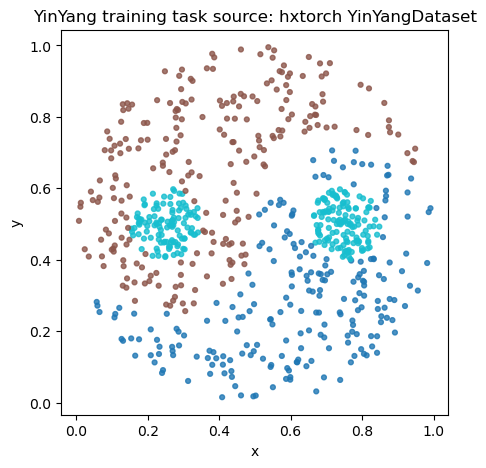

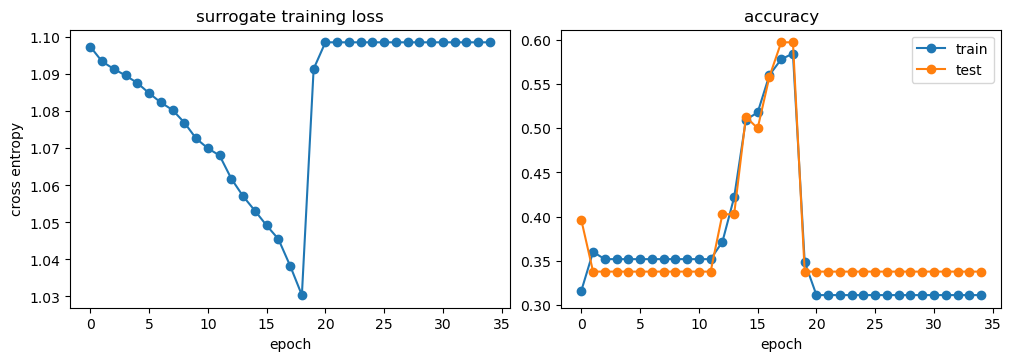

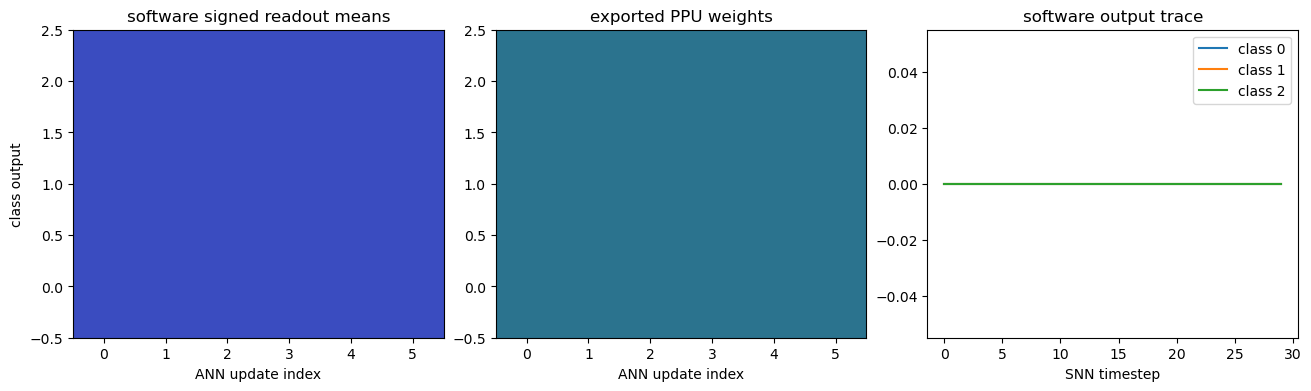

In [150]:
plot_yinyang_like_data(make_yinyang_like_tensors(n_samples=768, seed=5))

surrogate_model, yinyang_data, surrogate_history = train_surrogate_release_modulator(
    n_samples=768,
    epochs=35,
    batch_size=64,
    lr=1e-3,
    seed=5,
)
plot_surrogate_training(surrogate_history)

hardware_schedule, surrogate_diag, surrogate_pred, surrogate_label = inspect_surrogate_modulated_sample(
    surrogate_model,
    yinyang_data,
    sample_index=0,
)


PPU mean_weight: [24, 24, 24, 24, 24, 24]
PPU first_weight: [24, 24, 24, 24, 24, 24]
output spike count: 0


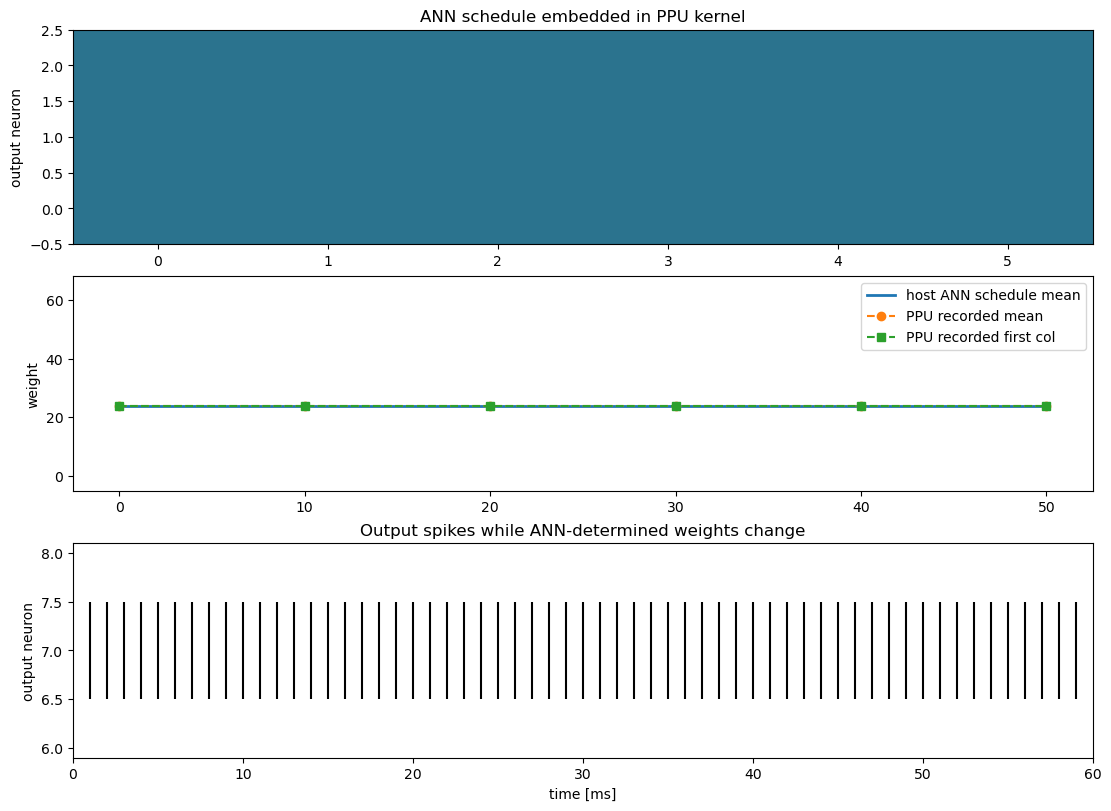

In [151]:
surrogate_ppu_mean, surrogate_ppu_first, surrogate_ppu_spikes, surrogate_ppu_projection = \
    run_surrogate_schedule_on_ppu(
        hardware_schedule,
        period=10,
    )


## Pong-Style SNN Edited By An ANN Modulator

This follows the working `ts_07-pong.ipynb` pattern more closely: a PyNN SNN receives position-coded input spikes, a plastic projection connects input positions to output positions, and a PPU rule edits the projection weights while the run is in progress.

The off-chip ANN learns a release-site output field for each input/ball position. We then export a sequence of ANN-generated weight matrices and let the PPU apply one matrix per runtime window. This is the clean "train off chip, test on chip" version of editing an SNN while it runs.


In [152]:
class PongStyleANNModulator(nn.Module):
    """Off-chip ANN that emits release-site amplitudes/spreads for output positions."""

    def __init__(self, n_positions=12, n_release_sites=4, hidden=32, seed=13):
        super().__init__()
        torch.manual_seed(seed)
        self.n_positions = int(n_positions)
        self.n_release_sites = int(n_release_sites)
        self.sites = release_sites_1d_torch(n_positions, n_release_sites)
        self.net = nn.Sequential(
            nn.Linear(n_positions + 2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2 * n_release_sites),
        )

    def forward(self, position_index, phase=None):
        if phase is None:
            phase = torch.zeros(position_index.numel(), 2, device=position_index.device)
        one_hot = F.one_hot(position_index.long(), num_classes=self.n_positions).float()
        raw = self.net(torch.cat([one_hot, phase.float()], dim=1))
        amps = torch.tanh(raw[:, :self.n_release_sites])
        spreads = torch.sigmoid(raw[:, self.n_release_sites:])
        field = release_field_1d_torch(amps, spreads, self.sites, self.n_positions)
        return field, amps, spreads


def train_pong_style_ann_modulator(n_positions=12, n_release_sites=4, epochs=300, lr=3e-3, seed=13):
    torch.manual_seed(seed)
    model = PongStyleANNModulator(n_positions=n_positions, n_release_sites=n_release_sites, seed=seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    positions = torch.arange(n_positions)
    phase = torch.zeros(n_positions, 2)
    history = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        scores, amps, spreads = model(positions, phase)
        # The output field acts like output-neuron drive for the active input row.
        loss = F.cross_entropy(scores * 6.0, positions)
        # Keep release fields smooth-ish and finite, not giant brittle peaks.
        loss = loss + 0.002 * (amps.pow(2).mean() + spreads.pow(2).mean())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        with torch.no_grad():
            acc = float((scores.argmax(dim=1) == positions).float().mean().item())
        history.append((float(loss.item()), acc))
        if epoch in {1, 25, 50, 100, 200, epochs}:
            print(f"epoch {epoch:03d} | loss {loss.item():.3f} | position acc {acc:.2f}")
    return model, history


def build_pong_style_matrix_schedule(model, position_sequence, high=63, low=0):
    model.eval()
    positions = torch.tensor(position_sequence, dtype=torch.long)
    phase_t = torch.linspace(0, 2 * torch.pi, len(position_sequence))
    phase = torch.stack([torch.sin(phase_t), torch.cos(phase_t)], dim=1)
    with torch.no_grad():
        fields, amps, spreads = model(positions, phase)
    # Convert ANN field to hardware excitatory weights. Softmax keeps the winner
    # high while still leaving a graded release shape around it.
    vectors = torch.softmax(fields * 8.0, dim=1)
    vectors = low + (high - low) * vectors / vectors.max(dim=1, keepdim=True).values.clamp_min(1e-6)
    vectors = torch.round(vectors).clamp(0, 63).to(torch.uint8).cpu().numpy()

    n_positions = model.n_positions
    schedule = np.zeros((len(position_sequence), n_positions, n_positions), dtype=np.uint8)
    for update, input_position in enumerate(position_sequence):
        schedule[update, int(input_position), :] = vectors[update]
    diagnostics = {
        "positions": np.asarray(position_sequence, dtype=int),
        "vectors": vectors,
        "fields": fields.cpu().numpy(),
        "amps": amps.cpu().numpy(),
        "spreads": spreads.cpu().numpy(),
        "sites": model.sites.cpu().numpy(),
    }
    return schedule, diagnostics


def plot_pong_style_schedule(schedule, diagnostics, period=10):
    positions = diagnostics["positions"]
    vectors = diagnostics["vectors"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    axes[0].plot([h[0] for h in pong_ann_history], label="loss") if 'pong_ann_history' in globals() else None
    axes[0].set_title("ANN training loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[1].imshow(vectors.T, aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[1].plot(np.arange(len(positions)), positions, color="white", linewidth=1.5, label="target")
    axes[1].set_title("ANN-generated active-row output vector")
    axes[1].set_xlabel("runtime update")
    axes[1].set_ylabel("output position")
    axes[1].legend(loc="upper right")
    axes[2].imshow(schedule.mean(axis=0), aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[2].set_title("mean matrix over run")
    axes[2].set_xlabel("output position")
    axes[2].set_ylabel("input position")


In [153]:
class PongStyleMatrixScheduleRule(pynn.PlasticityRule):
    """PPU rule that writes an ANN-generated input x output matrix each window."""

    def __init__(self, timer, schedule):
        self.schedule = np.asarray(schedule, dtype=np.uint8)
        self.num_periods, self.n_inputs, self.n_outputs = self.schedule.shape
        observables = {
            "active_row": pynn.PlasticityRule.ObservableArray(),
            "row_mean": pynn.PlasticityRule.ObservableArray(),
            "target_weight": pynn.PlasticityRule.ObservableArray(),
        }
        for name in observables:
            observables[name].type = pynn.PlasticityRule.ObservableArray.Type.uint8
            observables[name].size = 1
        super().__init__(timer=timer, observables=observables)

    def generate_kernel(self) -> str:
        matrices = []
        for matrix in self.schedule:
            rows = ["{" + ", ".join(str(int(v)) for v in row) + "}" for row in matrix]
            matrices.append("{\n" + ",\n".join(rows) + "\n}")
        matrix_literal = ",\n".join(matrices)
        return textwrap.dedent(f"""
        #include "grenade/vx/ppu/synapse_array_view_handle.h"
        #include "grenade/vx/ppu/neuron_view_handle.h"
        #include "libnux/vx/dls.h"
        #include <array>

        using namespace grenade::vx::ppu;
        using namespace libnux::vx;

        extern volatile PPUOnDLS ppu;
        uint32_t update_index = 0;
        uint8_t matrix_schedule[{self.num_periods}][{self.n_inputs}][{self.n_outputs}] = {{
{matrix_literal}
        }};

        void PLASTICITY_RULE_KERNEL(
            std::array<SynapseArrayViewHandle, 1>& synapses,
            std::array<NeuronViewHandle, 0>& /* neurons */,
            Recording& recording)
        {{
            if (synapses[0].hemisphere != ppu) {{
                return;
            }}
            if (update_index >= {self.num_periods}) {{
                return;
            }}

            uint8_t active_row = 0;
            uint8_t target_weight = 0;
            uint32_t row_sum = 0;
            for (size_t logical_row = 0; logical_row < {self.n_inputs}; ++logical_row) {{
                uint32_t sum = 0;
                for (size_t logical_col = 0; logical_col < {self.n_outputs}; ++logical_col) {{
                    sum += matrix_schedule[update_index][logical_row][logical_col];
                }}
                if (sum > row_sum) {{
                    row_sum = sum;
                    active_row = logical_row;
                }}
            }}

            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                vector_row_t weight_row;
                size_t logical_row = row % {self.n_inputs};
                for (size_t idx = 0; idx < synapses[0].columns.size(); ++idx) {{
                    auto const column = synapses[0].columns[idx];
                    uint8_t weight = matrix_schedule[update_index][logical_row][idx % {self.n_outputs}];
                    weight_row[column] = weight;
                    if (logical_row == active_row && idx == active_row) {{
                        target_weight = weight;
                    }}
                }}
                synapses[0].set_weights(weight_row, row);
            }}

            recording.active_row[0] = active_row;
            recording.row_mean[0] = row_sum / {self.n_outputs};
            recording.target_weight[0] = target_weight;
            update_index++;
        }}
        """)


def _matrix_observable(rule, name, num_periods):
    observed = rule.get_observable_array(name)[0]
    return np.array([int(observed[i].data[0]) for i in range(num_periods)])


In [154]:
def run_pong_style_ann_modulated_snn(schedule, position_sequence, period=10, spikes_per_window=8):
    schedule = np.asarray(schedule, dtype=np.uint8)
    num_periods, n_inputs, n_outputs = schedule.shape
    runtime = num_periods * period

    spiketrains = []
    for input_idx in range(n_inputs):
        times = []
        for update, active_input in enumerate(position_sequence):
            if int(active_input) != input_idx:
                continue
            start = update * period + 1.0
            stop = min((update + 1) * period - 1.0, runtime - 1.0)
            if stop > start:
                times.extend(np.linspace(start, stop, spikes_per_window).tolist())
        spiketrains.append(np.asarray(times))

    pynn.setup(enable_neuron_bypass=True)
    try:
        pop_input = pynn.Population(
            n_inputs,
            pynn.cells.SpikeSourceArray(spike_times=spiketrains),
        )
        pop_output = pynn.Population(n_outputs, pynn.cells.HXNeuron())
        pop_output.record(["spikes"])

        timer = pynn.Timer(start=0.0, period=float(period), num_periods=num_periods)
        plasticity_rule = PongStyleMatrixScheduleRule(timer=timer, schedule=schedule)
        synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=plasticity_rule,
            weight=0,
        )
        projection = pynn.Projection(
            pop_input,
            pop_output,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )

        pynn.run(runtime)
        active_row = _matrix_observable(plasticity_rule, "active_row", num_periods)
        row_mean = _matrix_observable(plasticity_rule, "row_mean", num_periods)
        target_weight = _matrix_observable(plasticity_rule, "target_weight", num_periods)
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains

        print("input sequence:", list(map(int, position_sequence)))
        print("PPU active_row:", active_row.tolist())
        print("PPU row_mean:", row_mean.tolist())
        print("PPU target_weight:", target_weight.tolist())
        print("output spike count:", sum(len(st) for st in output_spikes))
        plot_pong_style_hardware_result(position_sequence, output_spikes, schedule, active_row, target_weight, period, runtime)
        return active_row, row_mean, target_weight, output_spikes, projection
    finally:
        pynn.end()


def plot_pong_style_hardware_result(position_sequence, output_spikes, schedule, active_row, target_weight, period, runtime):
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
    axes[0].step(np.arange(len(position_sequence)) * period, position_sequence, where="post", label="input/target position")
    axes[0].step(np.arange(len(active_row)) * period, active_row, where="post", linestyle="--", label="PPU active row")
    axes[0].set_ylabel("position")
    axes[0].legend(loc="upper right")
    axes[0].set_title("Pong-style ANN-modulated SNN runtime sequence")

    axes[1].plot(np.arange(len(target_weight)) * period, target_weight, "o-", label="target weight")
    axes[1].plot(np.arange(schedule.shape[0]) * period, schedule.max(axis=(1, 2)), "s--", label="matrix max")
    axes[1].set_ylabel("weight")
    axes[1].set_ylim(-5, 68)
    axes[1].legend(loc="upper right")

    spike_times = [np.asarray(st.base) for st in output_spikes]
    if spike_times:
        axes[2].eventplot(spike_times, lineoffsets=np.arange(len(spike_times)), colors="tab:red")
    axes[2].step(np.arange(len(position_sequence)) * period, position_sequence, where="post", color="black", alpha=0.35)
    axes[2].set_xlim(0, runtime)
    axes[2].set_ylabel("output position")
    axes[2].set_xlabel("time [ms]")


epoch 001 | loss 2.546 | position acc 0.08
epoch 025 | loss 2.170 | position acc 0.17
epoch 050 | loss 1.534 | position acc 0.50
epoch 100 | loss 0.635 | position acc 0.75
epoch 200 | loss 0.341 | position acc 0.83
epoch 300 | loss 0.318 | position acc 0.83


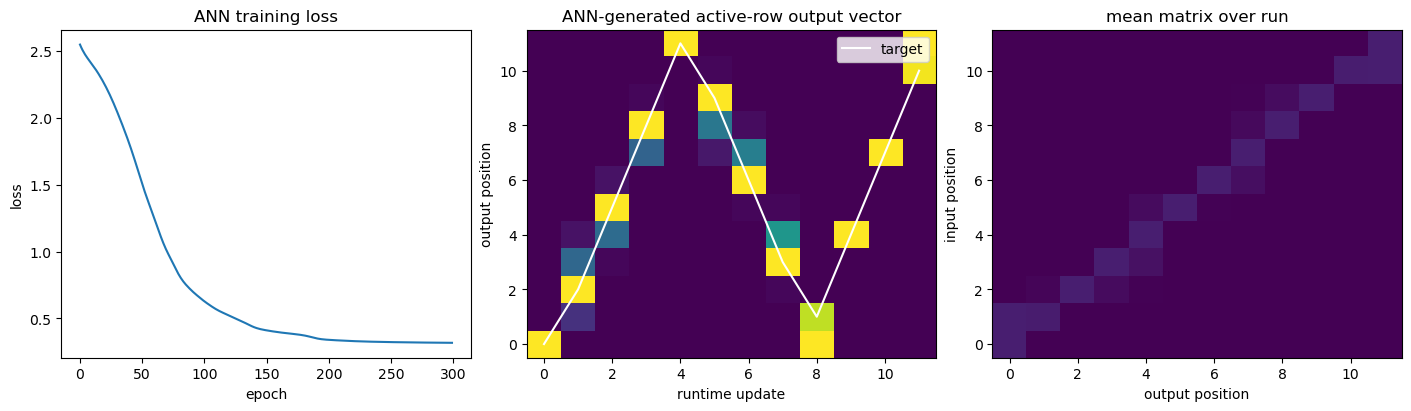

In [155]:
pong_ann_model, pong_ann_history = train_pong_style_ann_modulator(
    n_positions=12,
    n_release_sites=4,
    epochs=300,
    lr=3e-3,
    seed=13,
)

pong_position_sequence = [0, 2, 5, 8, 11, 9, 6, 3, 1, 4, 7, 10]
pong_matrix_schedule, pong_matrix_diagnostics = build_pong_style_matrix_schedule(
    pong_ann_model,
    pong_position_sequence,
)
plot_pong_style_schedule(pong_matrix_schedule, pong_matrix_diagnostics, period=10)


input sequence: [0, 2, 5, 8, 11, 9, 6, 3, 1, 4, 7, 10]
PPU active_row: [0, 2, 5, 8, 11, 9, 6, 3, 1, 4, 7, 10]
PPU row_mean: [5, 8, 7, 7, 5, 7, 7, 8, 10, 5, 5, 10]
PPU target_weight: [63, 63, 63, 63, 63, 63, 63, 63, 57, 63, 63, 62]
output spike count: 128


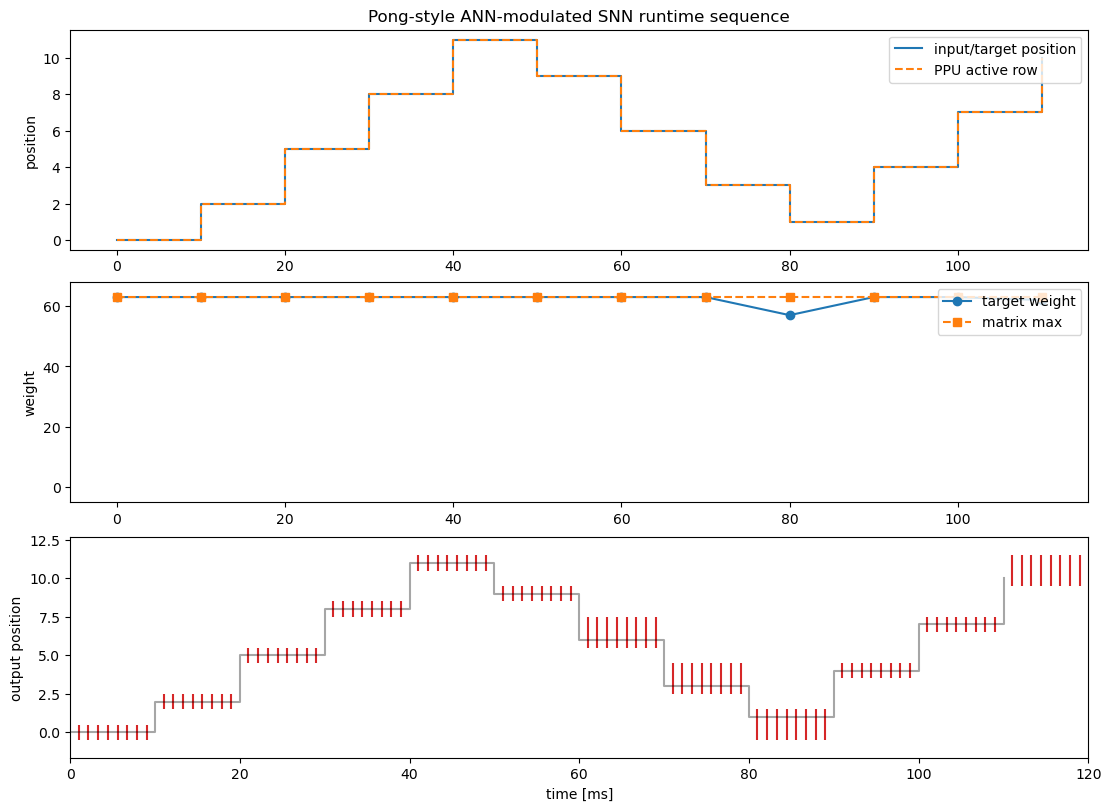

In [156]:
pong_active_row, pong_row_mean, pong_target_weight, pong_output_spikes, pong_projection = \
    run_pong_style_ann_modulated_snn(
        pong_matrix_schedule,
        pong_position_sequence,
        period=10,
        spikes_per_window=8,
    )


## How to interpret the result

If the PPU rule ran, `debug_runs` should be nonzero on at least one hemisphere and `debug_rows` should show how many placed synapse rows were supplied to the kernel.

The expected behavioral smoke test is simple: baseline uses weight `63`, while the PPU run zeros the weights at `t=5`, before the input spikes at `t=10`, `15`, `20`, and `30`. If the PPU write is taking effect, the PPU run should produce fewer output spikes than the baseline.

If this compiles but `debug_rows` is zero, the kernel is running on the wrong hemisphere or the synapse view shape does not match the hxtorch projection. If it fails to compile with a signature mismatch, try changing `std::array<SynapseArrayViewHandle, 2>` to `std::array<SynapseArrayViewHandle, 1>`; PyNN examples use one view per plastic projection, while hxtorch signed synapses often expose two views.
